### Data was taken from https://www.ecad.eu/dailydata/predefinedseries.php# in July 2021
Note: weather station 244 ('STAID000244') is located in ZUERICH/FLUNTERN, SWITZERLAND

In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_squared_log_error, mean_absolute_error, r2_score

## Data retrieval, selection and framing

In [7]:
def txtToDF(filename,rename_col):    
    df = pd.read_csv(filename,header=15, index_col=0)
    df = df.rename(columns={'    DATE':'DATE',f'   {rename_col}':rename_col})
    df['date_time'] = pd.to_datetime(df['DATE'], format='%Y%m%d')
    df['year'] = pd.DatetimeIndex(df['date_time']).year
    df['month'] = pd.DatetimeIndex(df['date_time']).month                        
    df['year_month'] = df['date_time'].dt.strftime('%Y-%m')
    df = df[[rename_col, 'year', 'month', 'year_month', 'date_time']]                        
    df.dropna(inplace=True)
    df_filter = df[(df['year']>=1950)&(df['year']<2020)]    
    return df_filter

df = txtToDF('TG_STAID000244.txt','TG')
df.head()

,TG,year,month,year_month,date_time
STAID,,,,,
244,-27,1950,1,1950-01,1950-01-01
244,17,1950,1,1950-01,1950-01-02
244,16,1950,1,1950-01,1950-01-03
244,8,1950,1,1950-01,1950-01-04
244,54,1950,1,1950-01,1950-01-05


## First view: Get to know the data

In [10]:
def plot_mean(df_year_mean, df_month_mean, df_year_month_mean, temp_name):
    
    plt.figure(figsize=(18,6))  
    
    plt.subplot(1,3,1)
    plt.plot(df_month_mean[temp_name])
    plt.xlabel('month')
    plt.ylabel(temp_name)

    plt.subplot(1,3,2)
    plt.plot(df_year_month_mean[temp_name])
    plt.xlabel('year_month')
    plt.ylabel(temp_name)
    
    plt.subplot(1,3,3)
    plt.plot(df_year_mean[temp_name])
    plt.xlabel('year')
    plt.ylabel(temp_name)   
    
    plt.tight_layout()
    plt.show()

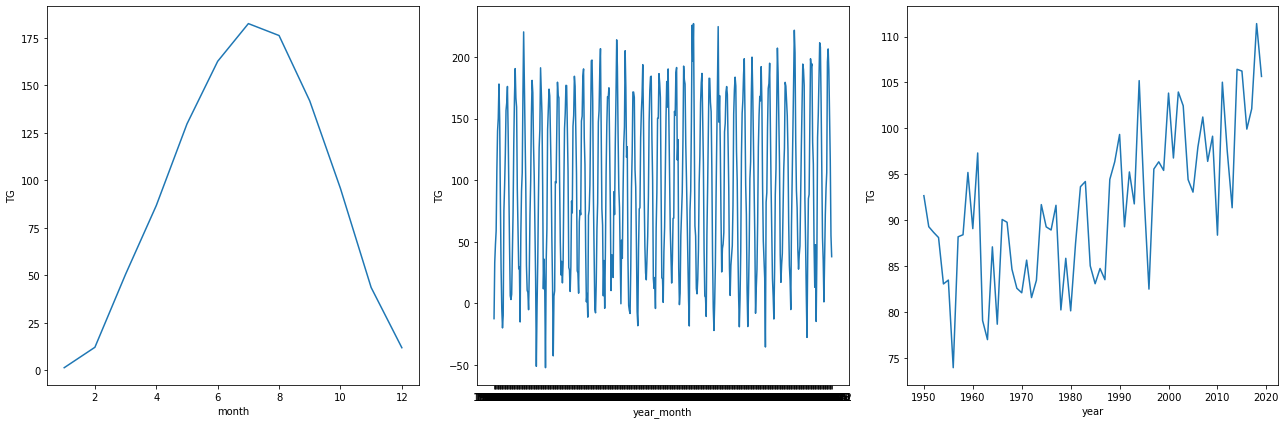

In [11]:
def calculate_mean(df, temp_name):
    df_year_mean = df.groupby(['year']).mean()
    df_month_mean = df.groupby(['month']).mean()
    df_filter_10y = df[(df['year']>=1980)&(df['year']<2020)]
    df_year_month_mean = df_filter_10y.groupby(['year_month']).mean()
    plot_mean(df_year_mean, df_month_mean, df_year_month_mean, temp_name) 
    return df_year_mean, df_month_mean, df_year_month_mean
    
df_year_meanTG, df_month_meanTG, df_year_month_meanTG = calculate_mean(df, 'TG')

## Linear Model

### Generate lagged data (1-12 months) for auto linear regression

In [13]:
def generate_lagData(df, feature_name):
    for i in range(1,13):
        df[f'{feature_name} -{i}month'] = df[feature_name].shift(i)
    df.dropna(inplace=True)  
    df.set_index(df['year_month'], inplace=True)
    return df 

df_feat_TG = generate_lagData(df,'TG')
df_feat_TG.tail()

,TG,year,month,year_month,date_time,TG -1month,TG -2month,TG -3month,TG -4month,TG -5month,TG -6month,TG -7month,TG -8month,TG -9month,TG -10month,TG -11month,TG -12month
year_month,,,,,,,,,,,,,,,,,
2019-12,49,2019,12,2019-12,2019-12-27,27.0,57.0,56.0,47.0,51.0,49.0,75.0,63.0,81.0,79.0,58.0,91.0
2019-12,18,2019,12,2019-12,2019-12-28,49.0,27.0,57.0,56.0,47.0,51.0,49.0,75.0,63.0,81.0,79.0,58.0
2019-12,-9,2019,12,2019-12,2019-12-29,18.0,49.0,27.0,57.0,56.0,47.0,51.0,49.0,75.0,63.0,81.0,79.0
2019-12,-11,2019,12,2019-12,2019-12-30,-9.0,18.0,49.0,27.0,57.0,56.0,47.0,51.0,49.0,75.0,63.0,81.0
2019-12,-4,2019,12,2019-12,2019-12-31,-11.0,-9.0,18.0,49.0,27.0,57.0,56.0,47.0,51.0,49.0,75.0,63.0


### Heatmap

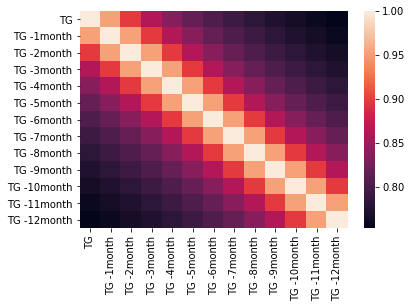

In [14]:
def plot_heatmap(df_feat):
    sns.heatmap(df_feat.drop(['year', 'month', 'year_month', 'date_time'], axis=1).corr())
    
plot_heatmap(df_feat_TG)

### Data Assignment (Train and Test Data)

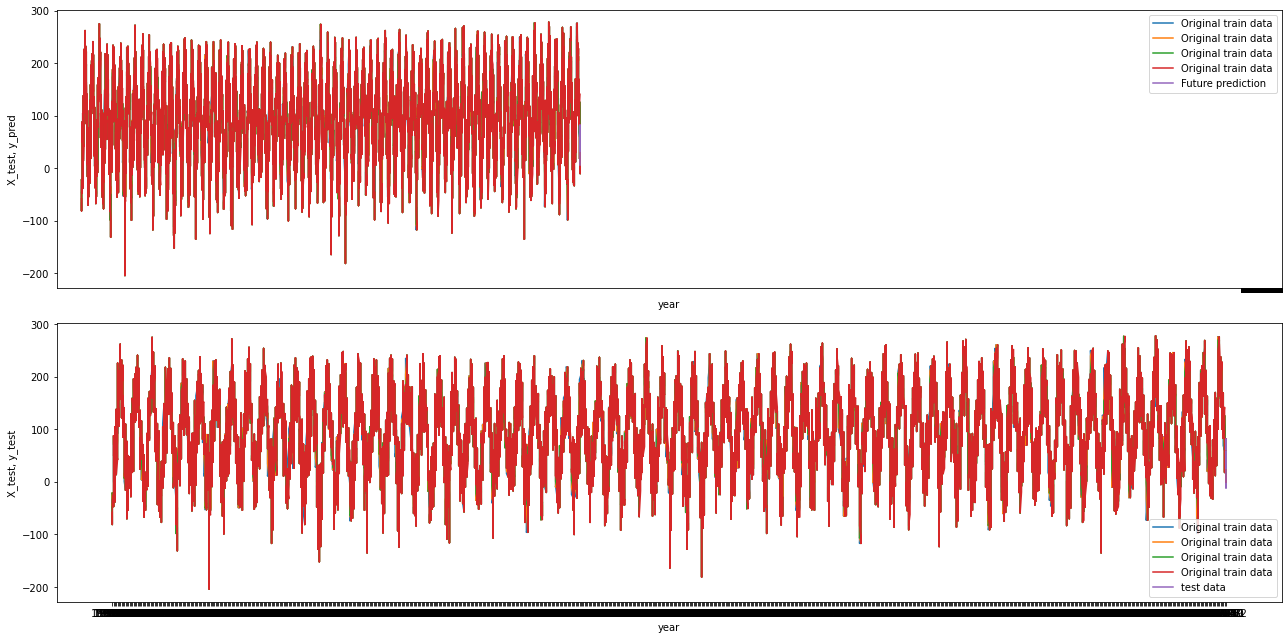

In [15]:
def lin_reg(df, temp_name):
    features = [f'{temp_name} -2month',f'{temp_name} -3month',f'{temp_name} -4month',f'{temp_name} -5month']
    X_train = df.iloc[:-15][features]  # lag data
    X_test = df.iloc[-15:][features]   # lag data
    y_train = df.iloc[:-15][temp_name] # real data
    y_test = df.iloc[-15:][temp_name]  # real data
    
    # fit and predict
    m = LinearRegression()
    m.fit(X_train, y_train)
    y_pred = m.predict(X_test)
 
    # plot linear regression
    plt.figure(figsize=(18,9))
    
    plt.subplot(2,1,1)
    plt.plot(X_train, label = 'Original train data')
    plt.plot(X_test.index, y_pred, label = 'Future prediction')
    plt.xlabel('year') 
    plt.ylabel('X_test, y_pred') 
    plt.xticks(df['year'])
    plt.legend()
    #plt.xlabel()
    
    plt.subplot(2,1,2)
    plt.plot(X_train, label = 'Original train data')
    plt.plot(X_test.index, y_test, label = 'test data')
    plt.xlabel('year') 
    plt.ylabel('X_test, y_test') 
    plt.legend()
        
    plt.tight_layout()
    plt.show()   
    
lin_reg(df_feat_TG, 'TG')

In [17]:
df_year_month_meanTG

,TG,year,month
year_month,,,
1980-01-01,-12.451613,1980.0,1.0
1980-02-01,33.275862,1980.0,2.0
1980-03-01,47.774194,1980.0,3.0
1980-04-01,58.900000,1980.0,4.0
1980-05-01,107.903226,1980.0,5.0
...,...,...,...
2019-08-01,189.354839,2019.0,8.0
2019-09-01,150.433333,2019.0,9.0
2019-10-01,116.419355,2019.0,10.0


## SARIMA (Seasonal Auto-Regressive Integrated Moving Average)
### Convert index to date-time-index and assign the temperatures to y

In [16]:
y = df_year_month_meanTG
y.index = pd.to_datetime(y.index, format='%Y-%m')
y = y['TG']
y

year_month
1980-01-01    -12.451613
1980-02-01     33.275862
1980-03-01     47.774194
1980-04-01     58.900000
1980-05-01    107.903226
                 ...    
2019-08-01    189.354839
2019-09-01    150.433333
2019-10-01    116.419355
2019-11-01     55.033333
2019-12-01     37.903226
Name: TG, Length: 480, dtype: float64

### Generate combinations of p, q and q triplets

In [18]:
import itertools
import warnings
import statsmodels.api as sm
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

# Define the p, d and q parameters to take any value between 0 and 2
p = d = q = range(0, 2)

# Generate all different combinations of p, q and q triplets
pdq = list(itertools.product(p, d, q))

# Generate all different combinations of seasonal p, q and q triplets
seasonal_pdq = [(x[0], x[1], x[2], 12) for x in list(itertools.product(p, d, q))]

print('Examples of parameter combinations for Seasonal ARIMA...')
print('SARIMAX: {} x {}'.format(pdq[1], seasonal_pdq[1]))
print('SARIMAX: {} x {}'.format(pdq[1], seasonal_pdq[2]))
print('SARIMAX: {} x {}'.format(pdq[2], seasonal_pdq[3]))
print('SARIMAX: {} x {}'.format(pdq[2], seasonal_pdq[4]))

Examples of parameter combinations for Seasonal ARIMA...
SARIMAX: (0, 0, 1) x (0, 0, 1, 12)
SARIMAX: (0, 0, 1) x (0, 1, 0, 12)
SARIMAX: (0, 1, 0) x (0, 1, 1, 12)
SARIMAX: (0, 1, 0) x (1, 0, 0, 12)


### Akaike's Information Criterion (AIC)

In [19]:
warnings.filterwarnings("ignore")

for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            mod = sm.tsa.statespace.SARIMAX(y,
                                            order=param,
                                            seasonal_order=param_seasonal,
                                            enforce_stationarity=False,
                                            enforce_invertibility=False)
            results = mod.fit()
            print('ARIMA{}x{}12 - AIC:{}'.format(param, param_seasonal, results.aic))
        except:
            continue

ARIMA(0, 0, 0)x(0, 0, 0, 12)12 - AIC:5920.160522535829
ARIMA(0, 0, 0)x(0, 0, 1, 12)12 - AIC:5315.882634529848
ARIMA(0, 0, 0)x(0, 1, 0, 12)12 - AIC:4358.658150733394
ARIMA(0, 0, 0)x(0, 1, 1, 12)12 - AIC:3968.8454123699603
ARIMA(0, 0, 0)x(1, 0, 0, 12)12 - AIC:4365.418929922024
ARIMA(0, 0, 0)x(1, 0, 1, 12)12 - AIC:4064.95554576426
ARIMA(0, 0, 0)x(1, 1, 0, 12)12 - AIC:4112.580422180567
ARIMA(0, 0, 0)x(1, 1, 1, 12)12 - AIC:3968.4671726560073
ARIMA(0, 0, 1)x(0, 0, 0, 12)12 - AIC:5400.855100519593
ARIMA(0, 0, 1)x(0, 0, 1, 12)12 - AIC:5000.607906498399
ARIMA(0, 0, 1)x(0, 1, 0, 12)12 - AIC:4348.5609006759505
ARIMA(0, 0, 1)x(0, 1, 1, 12)12 - AIC:3958.655654967183
ARIMA(0, 0, 1)x(1, 0, 0, 12)12 - AIC:4365.85695747775
ARIMA(0, 0, 1)x(1, 0, 1, 12)12 - AIC:4053.7769933784125
ARIMA(0, 0, 1)x(1, 1, 0, 12)12 - AIC:4111.3340302591605
ARIMA(0, 0, 1)x(1, 1, 1, 12)12 - AIC:3957.472041738633
ARIMA(0, 1, 0)x(0, 0, 0, 12)12 - AIC:4914.370501111209
ARIMA(0, 1, 0)x(0, 0, 1, 12)12 - AIC:4677.288464344723
ARIMA(0

### Visualize 

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0753      0.049      1.533      0.125      -0.021       0.172
ma.L1         -1.0000      3.044     -0.328      0.743      -6.967       4.967
ar.S.L12      -0.0273      0.022     -1.228      0.220      -0.071       0.016
ma.S.L12      -1.0000     35.582     -0.028      0.978     -70.740      68.740
sigma2       309.6426   1.11e+04      0.028      0.978   -2.14e+04     2.2e+04


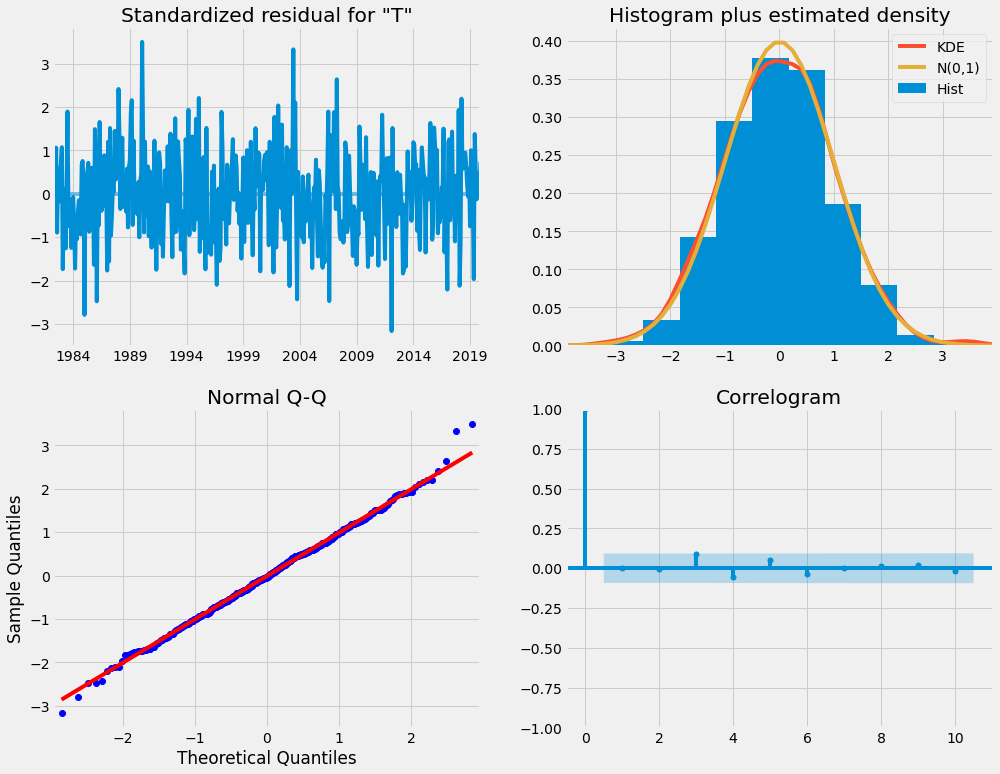

In [20]:
mod = sm.tsa.statespace.SARIMAX(y,
                                order=(1, 1, 1),
                                seasonal_order=(1, 1, 1, 12),
                                enforce_stationarity=False,
                                enforce_invertibility=False)
results = mod.fit()
print(results.summary().tables[1])
results.plot_diagnostics(figsize=(15, 12))
plt.show()

### Predict (static)

In [21]:
pred = results.get_prediction(start=pd.to_datetime('2005-01-01'), dynamic=False)
pred_ci = pred.conf_int()

### Plot observed and forecast (static)

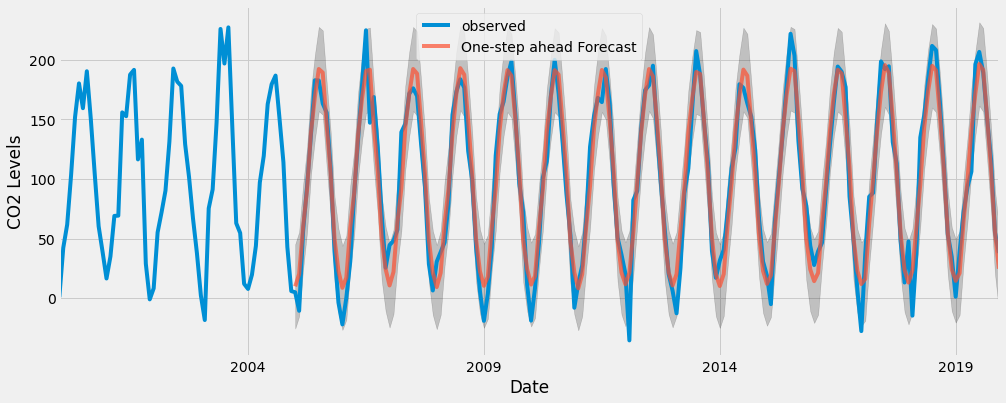

In [22]:
plt.figure(figsize=(15,6))
ax = y['2000':].plot(label='observed')

pred.predicted_mean.plot(ax=ax, label='One-step ahead Forecast', alpha=.7)

ax.fill_between(pred_ci.index,
                pred_ci.iloc[:, 0],
                pred_ci.iloc[:, 1], color='k', alpha=.2)

ax.set_xlabel('Date')
ax.set_ylabel('CO2 Levels')
plt.legend()
plt.show()

### Mean Squared Error (MSE) of the forecast

In [23]:
y_forecasted = pred.predicted_mean
y_truth = y['1998-01-01':]

mse = ((y_forecasted - y_truth) ** 2).mean()
print('The Mean Squared Error of our forecasts is {}'.format(round(mse, 2)))

The Mean Squared Error of our forecasts is 318.76


### Predict (dynamic)

In [26]:
pred_dynamic = results.get_prediction(start=pd.to_datetime('1998-01-01'), dynamic=True, full_results=True)
pred_dynamic_ci = pred_dynamic.conf_int()

### Plot observed and forecast (dynamic)

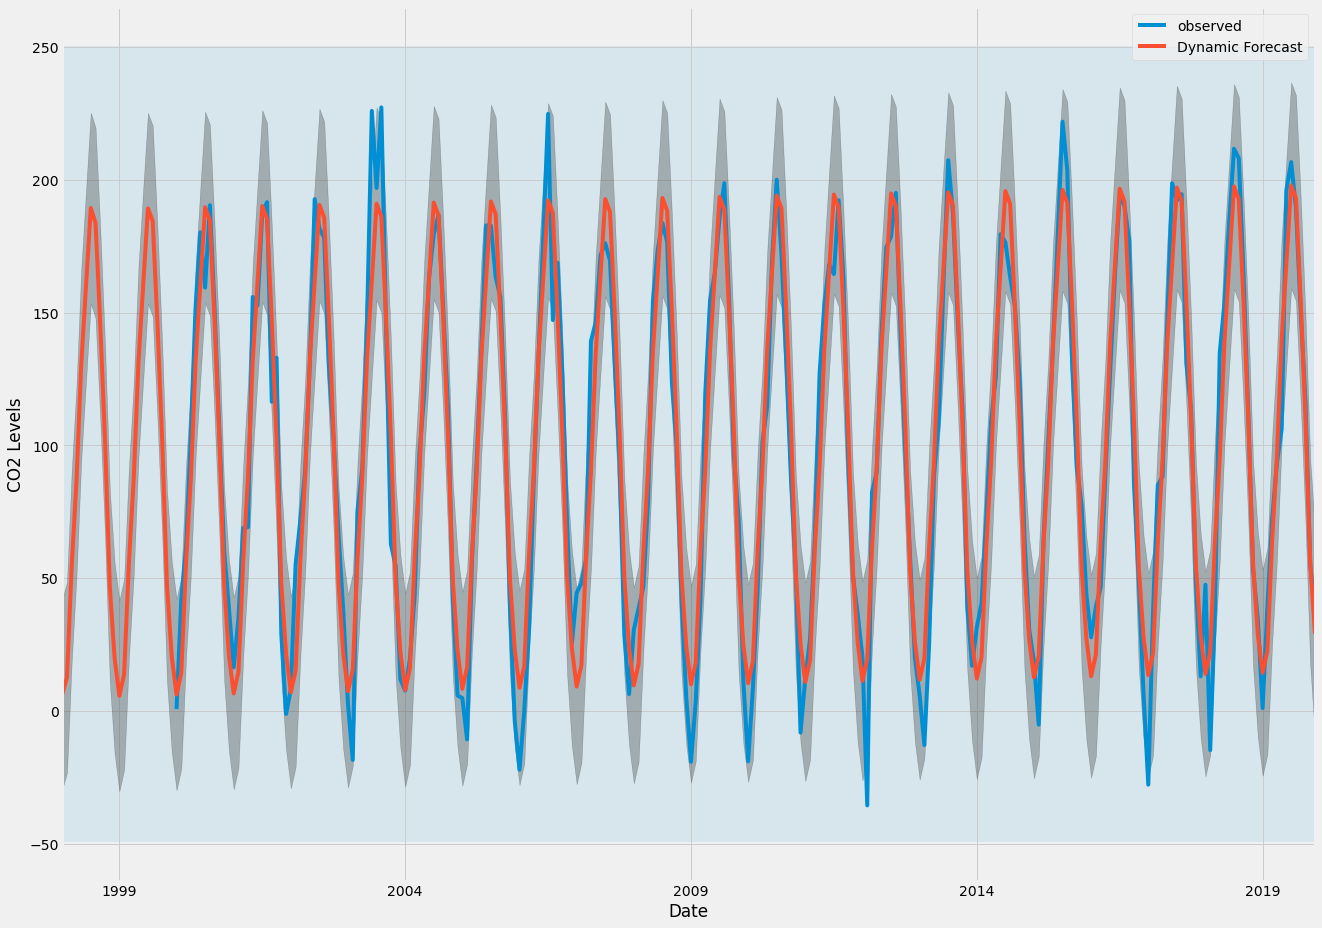

In [27]:
ax = y['2000':].plot(label='observed', figsize=(20, 15))
pred_dynamic.predicted_mean.plot(label='Dynamic Forecast', ax=ax)

ax.fill_between(pred_dynamic_ci.index,
                pred_dynamic_ci.iloc[:, 0],
                pred_dynamic_ci.iloc[:, 1], color='k', alpha=.25)

ax.fill_betweenx(ax.get_ylim(), pd.to_datetime('1998-01-01'), y.index[-1],
                 alpha=.1, zorder=-1)

ax.set_xlabel('Date')
ax.set_ylabel('CO2 Levels')

plt.legend()
plt.show()

### Mean Squared Error (MSE) of the Forecast (dynamic)

In [28]:
y_forecasted = pred_dynamic.predicted_mean
y_truth = y['1998-01-01':]

mse = ((y_forecasted - y_truth) ** 2).mean()
print('The Mean Squared Error of our forecasts is {}'.format(round(mse, 2)))

The Mean Squared Error of our forecasts is 321.11


### Get Forecast 500 Steps ahead in Future

In [29]:
pred_uc = results.get_forecast(steps=500)
pred_ci = pred_uc.conf_int()

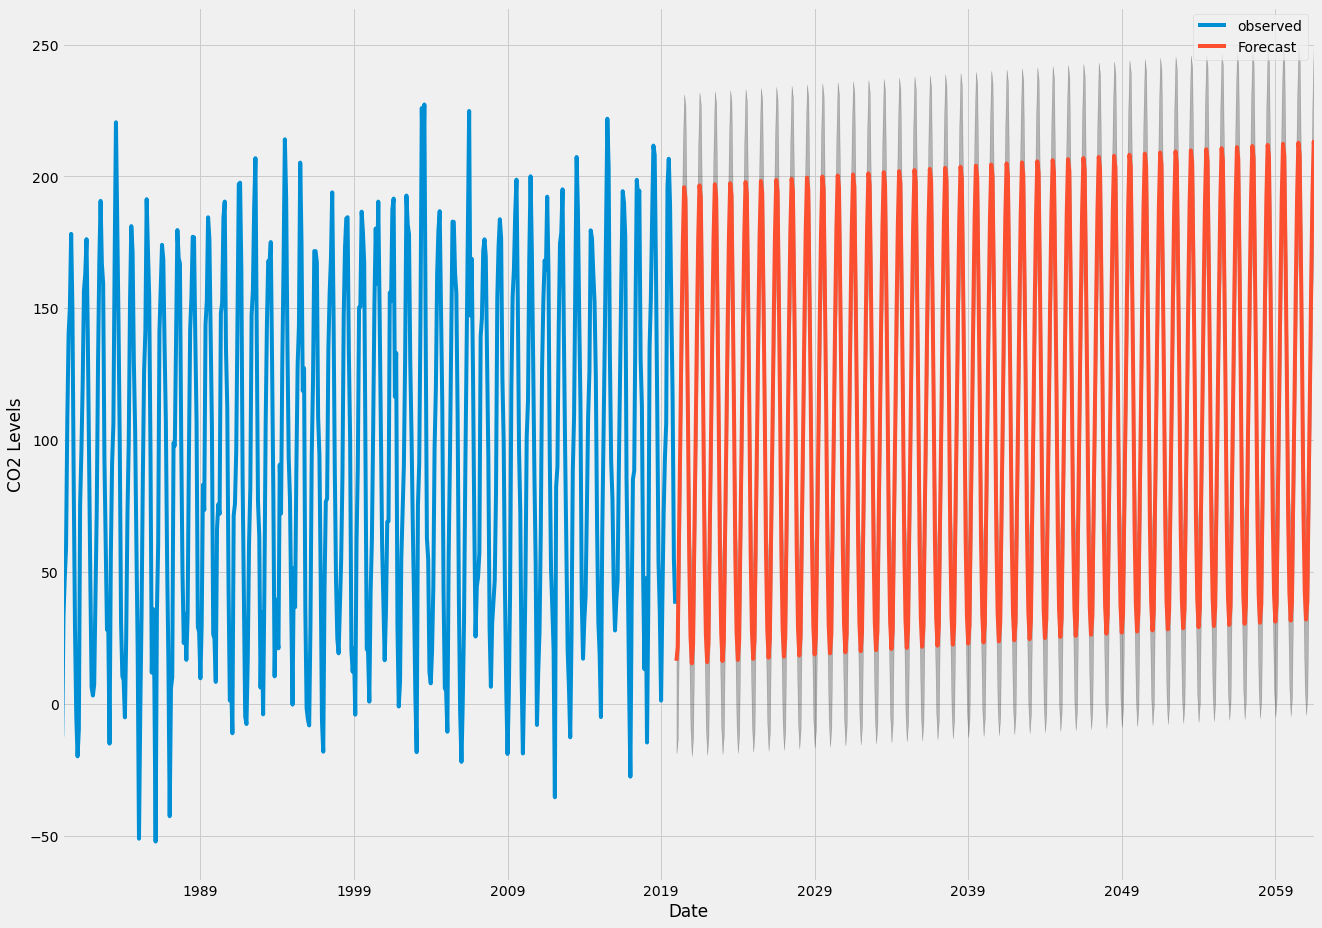

In [30]:
ax = y.plot(label='observed', figsize=(20, 15))
pred_uc.predicted_mean.plot(ax=ax, label='Forecast')
ax.fill_between(pred_ci.index,
                pred_ci.iloc[:, 0],
                pred_ci.iloc[:, 1], color='k', alpha=.25)
ax.set_xlabel('Date')
ax.set_ylabel('CO2 Levels')

plt.legend()
plt.show()

## Decompose Data

,TG,seasonal,trend,residuals
year,,,,
1950,92.676712,-3.195321,NaN,NaN
1951,89.301370,-1.530641,NaN,NaN
1952,88.677596,2.478452,NaN,NaN
1953,88.117808,-1.209043,NaN,NaN
1954,83.068493,3.166858,NaN,NaN
1955,83.487671,1.513357,NaN,NaN
1956,73.953552,-4.150880,87.561365,-9.456933
1957,88.202740,-1.308372,86.483054,3.028058
1958,88.424658,3.329044,85.905380,-0.809767


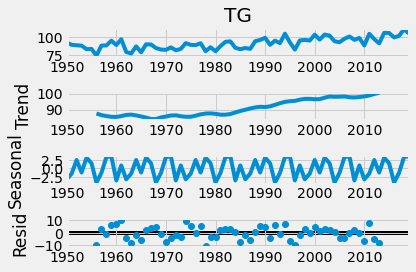

In [44]:
def decompose(df,temp_name):
    
    sdr = seasonal_decompose(df[temp_name], freq=12, model='additive')
    sdr.plot()
    None # to avoid getting 2 similar plots (bug)
    
    # create new dataFrame with temp, seasonal, trend, residuals
    results = pd.DataFrame(data = {temp_name:df[temp_name], \
            'seasonal':sdr.seasonal, 'trend':sdr.trend, 'residuals':sdr.resid})
    return results

results_TG = decompose(df_year_meanTG, 'TG')
results_TG.head(15)

### First view on Transformations

In [46]:
def transData(df,temp_name):

    # diff: calculate difference to the past year as absolut value
    df['diff'] = df[temp_name].diff()

    # pct change: calculate difference to the past year as relative value
    df['pct_change'] = df[temp_name].pct_change()

    # log: calculate log values to get rid of heteroscedasticity and to remove exponential growth
    df['log'] = np.log(df[temp_name])

transData(df_year_month_meanTG,'TG')
df_year_month_meanTG

,TG,year,month,diff,pct change,log,pct_change
year_month,,,,,,,
1980-01-01,-12.451613,1980.0,1.0,NaN,NaN,NaN,NaN
1980-02-01,33.275862,1980.0,2.0,45.727475,-3.672414,3.504832,-3.672414
1980-03-01,47.774194,1980.0,3.0,14.498331,0.435701,3.866486,0.435701
1980-04-01,58.900000,1980.0,4.0,11.125806,0.232883,4.075841,0.232883
1980-05-01,107.903226,1980.0,5.0,49.003226,0.831973,4.681235,0.831973
...,...,...,...,...,...,...,...
2019-08-01,189.354839,2019.0,8.0,-17.322581,-0.083815,5.243623,-0.083815
2019-09-01,150.433333,2019.0,9.0,-38.921505,-0.205548,5.013520,-0.205548
2019-10-01,116.419355,2019.0,10.0,-34.013978,-0.226107,4.757199,-0.226107


In [47]:
df_year_month_meanTG['month_means'] = df_year_month_meanTG.groupby('month')['pct change'].mean().to_list() * 40
TG = df_year_month_meanTG
TG.shape
TG['unseasonal'] = TG['pct_change'] - TG['month_means']
TG

,TG,year,month,diff,pct change,log,pct_change,month_means,unseasonal
year_month,,,,,,,,,
1980-01-01,-12.451613,1980.0,1.0,NaN,NaN,NaN,NaN,-0.217650,NaN
1980-02-01,33.275862,1980.0,2.0,45.727475,-3.672414,3.504832,-3.672414,-2.295380,-1.377034
1980-03-01,47.774194,1980.0,3.0,14.498331,0.435701,3.866486,0.435701,2.578366,-2.142665
1980-04-01,58.900000,1980.0,4.0,11.125806,0.232883,4.075841,0.232883,1.031517,-0.798634
1980-05-01,107.903226,1980.0,5.0,49.003226,0.831973,4.681235,0.831973,0.504743,0.327230
...,...,...,...,...,...,...,...,...,...
2019-08-01,189.354839,2019.0,8.0,-17.322581,-0.083815,5.243623,-0.083815,-0.015364,-0.068450
2019-09-01,150.433333,2019.0,9.0,-38.921505,-0.205548,5.013520,-0.205548,-0.208399,0.002851
2019-10-01,116.419355,2019.0,10.0,-34.013978,-0.226107,4.757199,-0.226107,-0.293724,0.067617


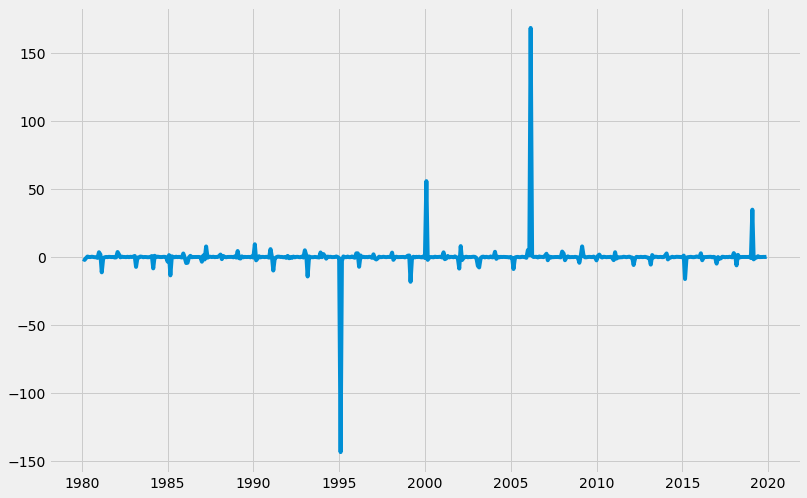

In [48]:
plt.figure(figsize=(12, 8))
plt.plot(TG['unseasonal'])

## ARIMA 2nd try

<AxesSubplot:title={'center':'Autocorrelation'}>

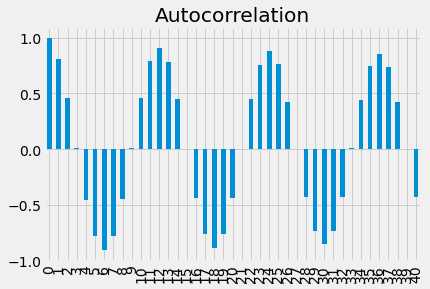

In [49]:
from statsmodels.tsa.stattools import acf,pacf
y = TG['TG']
pd.Series(acf(y, fft=False)).plot(
    kind='bar', title='Autocorrelation')

Figure(432x288)
Figure(432x288)


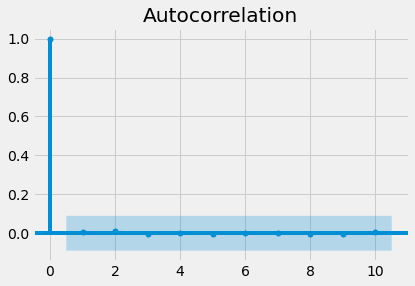

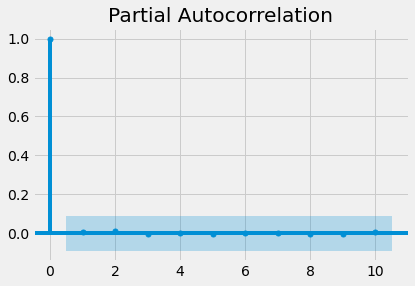

In [50]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

print(plot_acf(TG['unseasonal'].iloc[1:], lags=10))
print(plot_pacf(TG['unseasonal'].iloc[1:], lags=10))

### Assign Train and Test Data

In [51]:
y_train = TG['unseasonal'].iloc[1:-10]
y_test = TG['unseasonal'].iloc[-10:]

### Fit Data

In [52]:
from statsmodels.tsa.arima_model import ARIMA
from statsmodels.tsa.stattools import adfuller

m = ARIMA(y_train, (4,0,4))
m.initialize()
r = m.fit()

### Show Parameters, Confidence Interval, Summary

In [65]:
print("----------------------------Parameters----------------------------\n", r.params, "\n")
print("-----------------------Confidence Interval------------------------\n", r.conf_int(alpha=.1), "\n")
print("------------------------------Summary-----------------------------\n", r.summary())

----------------------------Parameters----------------------------
 const               4.894321e-03
ar.L1.unseasonal    1.403321e-02
ar.L2.unseasonal    1.391658e-04
ar.L3.unseasonal   -4.234537e-03
ar.L4.unseasonal    9.582624e-01
ma.L1.unseasonal   -7.127462e-03
ma.L2.unseasonal   -4.782089e-08
ma.L3.unseasonal    7.127462e-03
ma.L4.unseasonal   -1.000000e+00
dtype: float64 

-----------------------Confidence Interval------------------------
                          0         1
const            -0.406895  0.416683
ar.L1.unseasonal -0.025533  0.053600
ar.L2.unseasonal -0.025869  0.026147
ar.L3.unseasonal -0.043787  0.035318
ar.L4.unseasonal  0.932262  0.984263
ma.L1.unseasonal -0.031407  0.017152
ma.L2.unseasonal -0.020621  0.020621
ma.L3.unseasonal -0.017176  0.031431
ma.L4.unseasonal -1.020593 -0.979407 

------------------------------Summary-----------------------------
                               ARMA Model Results                              
Dep. Variable:             unse

### Forecast

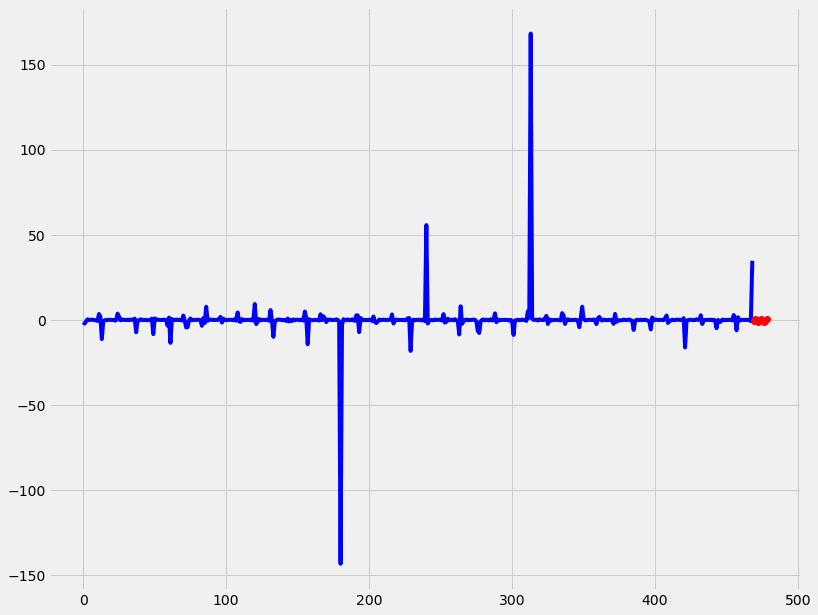

In [66]:
ypred, err, conf = r.forecast(steps=10) # predicted, error, confidence

plt.figure(figsize=(12, 10))
plt.plot(range(len(y_train)), y_train, color='blue')
plt.plot(range(len(y_train), len(y_train)+10), y_test[:10], color='black')
plt.plot(range(len(y_train), len(y_train)+10), ypred, color='red', marker='o')

In [70]:
df

,TG,year,month,year_month,date_time,TG -1month,TG -2month,TG -3month,TG -4month,TG -5month,TG -6month,TG -7month,TG -8month,TG -9month,TG -10month,TG -11month,TG -12month
year_month,,,,,,,,,,,,,,,,,
1950-01,-56,1950,1,1950-01,1950-01-25,-81.0,-66.0,-42.0,-48.0,-58.0,-57.0,-10.0,7.0,24.0,18.0,27.0,24.0
1950-01,-36,1950,1,1950-01,1950-01-26,-56.0,-81.0,-66.0,-42.0,-48.0,-58.0,-57.0,-10.0,7.0,24.0,18.0,27.0
1950-01,-21,1950,1,1950-01,1950-01-27,-36.0,-56.0,-81.0,-66.0,-42.0,-48.0,-58.0,-57.0,-10.0,7.0,24.0,18.0
1950-01,-31,1950,1,1950-01,1950-01-28,-21.0,-36.0,-56.0,-81.0,-66.0,-42.0,-48.0,-58.0,-57.0,-10.0,7.0,24.0
1950-01,-47,1950,1,1950-01,1950-01-29,-31.0,-21.0,-36.0,-56.0,-81.0,-66.0,-42.0,-48.0,-58.0,-57.0,-10.0,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-12,49,2019,12,2019-12,2019-12-27,27.0,57.0,56.0,47.0,51.0,49.0,75.0,63.0,81.0,79.0,58.0,91.0
2019-12,18,2019,12,2019-12,2019-12-28,49.0,27.0,57.0,56.0,47.0,51.0,49.0,75.0,63.0,81.0,79.0,58.0
2019-12,-9,2019,12,2019-12,2019-12-29,18.0,49.0,27.0,57.0,56.0,47.0,51.0,49.0,75.0,63.0,81.0,79.0


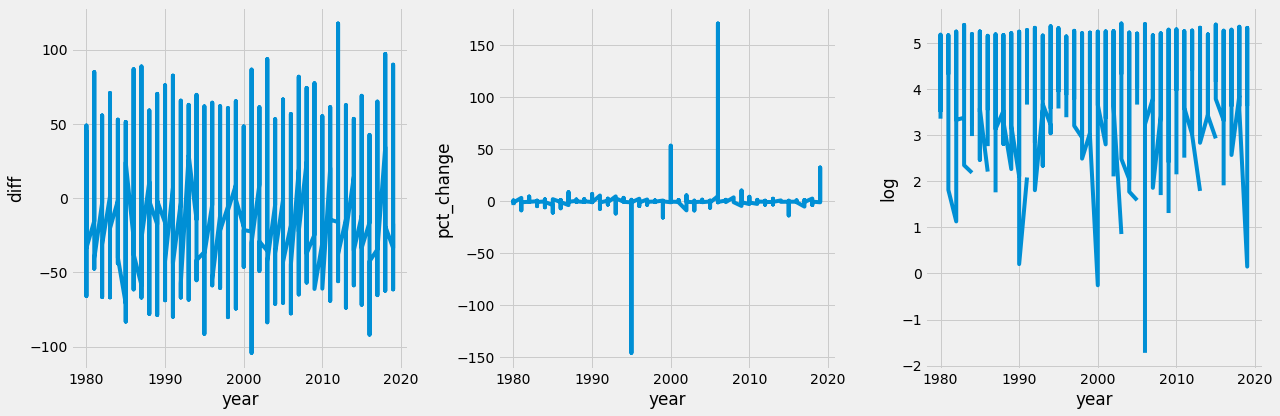

In [71]:
def plot_transData(df):

    # plot diff, pct change and log
    plt.figure(figsize=(18,6))

    plt.subplot(1,3,1)
    plt.plot(df['year'],df['diff'])
    plt.xlabel('year')
    plt.ylabel('diff')

    plt.subplot(1,3,2)
    plt.plot(df['year'],df['pct_change'])
    plt.xlabel('year')
    plt.ylabel('pct_change')

    plt.subplot(1,3,3)
    plt.plot(df['year'],df['log'])
    plt.xlabel('year')
    plt.ylabel('log')

    plt.tight_layout()
    plt.show()
    

plot_transData(TG)

In [73]:
# calculat mean values for diff, pct change and log
def calc_transData_mean(df, df_name):
    print(f'{df_name}_diff: ' , df['diff'].mean())
    print(f'{df_name}_pct_change: ', df['pct change'].mean())
    print(f'{df_name}_log: ', df['log'].mean(), '\n')
    
calc_transData_mean(TG, 'TG')

TG_diff:  0.10512492423732239
TG_pct_change:  0.037871795137150464
TG_log:  4.3167196016594245 



In [74]:
TG['diff'].mean()

0.10512492423732239

## Generate lagged data for auto linear regression

In [75]:
# generate lagged data (1-12 month) to enable auto linear regression
for i in range(1,13):
    TG[f'TG -{i}year'] = TG['TG'].shift(i)
df.head()

,TG,year,month,year_month,date_time,TG -1month,TG -2month,TG -3month,TG -4month,TG -5month,TG -6month,TG -7month,TG -8month,TG -9month,TG -10month,TG -11month,TG -12month
year_month,,,,,,,,,,,,,,,,,
1950-01,-56,1950,1,1950-01,1950-01-25,-81.0,-66.0,-42.0,-48.0,-58.0,-57.0,-10.0,7.0,24.0,18.0,27.0,24.0
1950-01,-36,1950,1,1950-01,1950-01-26,-56.0,-81.0,-66.0,-42.0,-48.0,-58.0,-57.0,-10.0,7.0,24.0,18.0,27.0
1950-01,-21,1950,1,1950-01,1950-01-27,-36.0,-56.0,-81.0,-66.0,-42.0,-48.0,-58.0,-57.0,-10.0,7.0,24.0,18.0
1950-01,-31,1950,1,1950-01,1950-01-28,-21.0,-36.0,-56.0,-81.0,-66.0,-42.0,-48.0,-58.0,-57.0,-10.0,7.0,24.0
1950-01,-47,1950,1,1950-01,1950-01-29,-31.0,-21.0,-36.0,-56.0,-81.0,-66.0,-42.0,-48.0,-58.0,-57.0,-10.0,7.0


In [80]:
TG.dropna(inplace=True)
features = ['TG -12year']

## Data Assignment to train and test data

In [81]:
X_train = TG.iloc[:-15][features]
X_test = TG.iloc[-15:][features]

y_train = TG.iloc[:-15]['TG']
y_test = TG.iloc[-15:]['TG']

In [82]:
from sklearn.linear_model import LinearRegression
m = LinearRegression()
m.fit(X_train, y_train)

LinearRegression()

In [83]:
y_pred = m.predict(X_test)

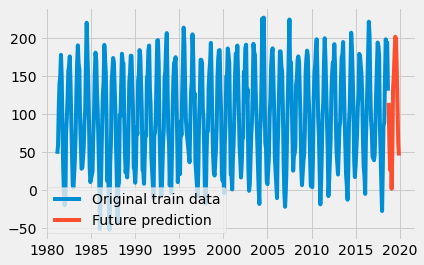

In [84]:
plt.plot(X_train, label = 'Original train data')
plt.plot(X_test.index, y_pred, label = 'Future prediction')
plt.legend()
#plt.xlabel(

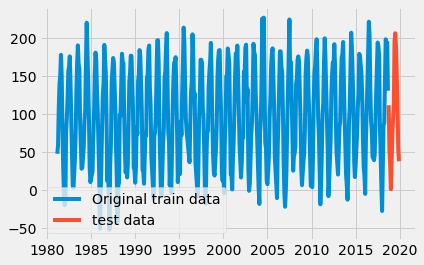

In [85]:
plt.plot(X_train, label = 'Original train data')
plt.plot(X_test.index, y_test, label = 'test data')
plt.legend()
#plt.xlabel()

## Cross Validation

In [87]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
rmsle = np.sqrt(mean_squared_log_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("MAE:", mae)
print("RMSE:", rmse)
print("RMSLE:", rmsle)
print("R2:", r2)

MSE: 630.0463040848124
MAE: 18.45723738356272
RMSE: 25.100723178522415
RMSLE: 1.1115007723326806
R2: 0.8374736976753775
